# Showcase

In this notebook, we showcase the most important methods and functions developed in the course of this project.

## Accessing the Data

To load all relevant data of a specific leaf, we use the `LeafDataset` class from `DatasetTools`. The argument `leaf_uid` specifies with leaf should be loaded. The keywords listed under the argument `load` specify which assets should be retrieved. To work on the full leaf, load `cropped_images` and `seg_masks`. To work on the ROI only, load `roi_leaf_images` and `roi_leaf_masks`. To obtain the ROIs registered with the piecewise affine approach, load `target_images` and `target_masks`.

In [1]:
import os
from DatasetTools.LeafImageSeries import LeafDataset

base_dir = '../leaf-image-sequences'
assert os.path.exists(base_dir), "Path to base directory invalid"
assert os.path.exists(base_dir+'/raw'), "Base directory empty"

leaf = LeafDataset(
    base_dir=base_dir,
    leaf_uid="ESWW0070020_2", 
    load=('target_images', 'target_masks', 'seg_masks', 'cropped_images', 'roi_leaf_images', 'roi_leaf_masks'),
    verbose=False
)

Processing series: 100%|██████████| 15/15 [00:12<00:00,  1.20it/s]


### Visualization

All visualization and plotting functions are collected in `plotting.py`. The most useful plotting functions will be showcased through the course of this notebook.

In [2]:
from plotting import plot_image_pair, plot_image_series, plot_img, plot_matches_conf, plot_match_coverage, plot_overlay, plot_img_transform

### Configurations

We use `.yaml` files for configuring our registration functions and experiments. In `configs/`, we provide a series of config files for various experimental configurations, namely:
- `default_s100.yaml`: The default configuration, with smoothing $=100$. It uses warp consistency and confidence-based filtering, and works on pre-rotated ROIs with eroded markers.
- `default_s0.yaml`: The default configuration, with smoothing $=0$.
- `no_consistency.yaml`: Does not use warp consistency.
- `grid_filter.yaml`: Uses grid-wise filtering instead of confidence-based filtering. 
- `cluster_filter.yaml`: Uses cluster-wise filtering instead of confidence-based filtering.
- `min_dist_filter.yaml`: Uses minimum distance filtering instead of confidence-based filtering.
- `full_leaf.yaml`: Works on the full leaf instead of just the ROI.
- `with_markers.yaml`: Doesn't erode markers.
- `unrotated_roi.yaml`: Doesn't pre-rotate the ROI.
- `unrotated_roi_hom.yaml`: Doesn't pre-rotate the ROI and uses a random homography instead of a fixed rotation during warp consistency.

The config files can be loaded with `load_config`:

In [3]:
from utils import load_config
# crop_img, convert_image_to_tensor, match_sizes_resize_batch

config = load_config("configs/default_s100.yaml")
config

{'smoothing': 100,
 'return_masks': True,
 'verbose': False,
 'image_preprocessing': {'img_scale': 'roi',
  'pre_rotate': True,
  'erase_markers': {'type': 'pixel_erosion', 'params': None}},
 'warp_consistency': {'consistency_tolerance': 5,
  'transform': {'type': 'rotation', 'params': {'rotation': -10}}},
 'match_filtering': {'filtering_strategy': 'confidence',
  'n_landmarks': 500,
  'n_landmarks_tol': 50,
  'min_conf': 0.5},
 'semi_sequential_criterion': {'criterion_type': 'coverage',
  'params': {'dist_threshold': 40}}}

## Preprocessing

Preprocessing consists of downscaling, removing superfluous background, masking out non-leaf background, erasing markers, and rotating the ROI to be aligned with the image axes.

Notable functions:
- `fetch_unmasked_image_mask_pair`: Fetches an unmasked leaf image and the corresponding mask.
- `fetch_unmasked_image_seq`: Fetches all unmasked leaf images and (optionally) the corresponding masks of the series.
- `fetch_image_mask_pair`: Fetches and preprocesses a time frame of a leaf and its corresponding mask.
- `fetch_masked_image_seq`:  Fetches and preprocesses all leaf images and (optionally) the corresponding masks of the series.

The two preprocessing functions can be configured using a dictionary as follows:

In [4]:
preprocessing_config = {
    'img_scale': 'roi', # or: 'full'
    'pre_rotate': True, 
    'erase_markers': {
        'type': 'pixel_erosion', # or: 'scaling_erosion'
        'params': {} # use default parameters
        }
    }

##### Example function calls:

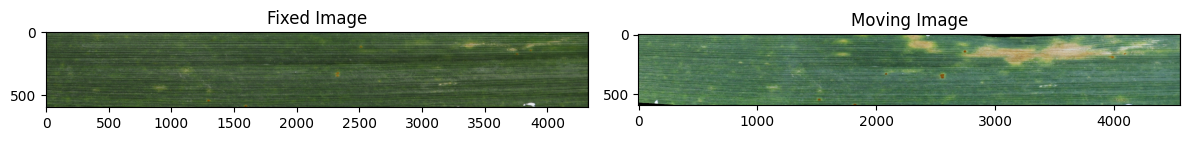

In [5]:
from masking import fetch_image_mask_pair

ind = 5
img_fixed, mask_fixed = fetch_image_mask_pair(leaf, 0, **config['image_preprocessing'])
img_moving, mask_moving = fetch_image_mask_pair(leaf, ind, **config['image_preprocessing'])
# or
# img_fixed, mask_fixed = fetch_image_mask_pair(leaf, 0, preprocessing_config)
# img_moving, mask_moving = fetch_image_mask_pair(leaf, ind, preprocessing_config)


_=plot_image_pair(img_fixed, img_moving, subtitle_1="Fixed Image", subtitle_2="Moving Image")

(Note that when retrieving individual images, they will not automatically be downscaled nor padded to have the same size. See `match_sizes_resize` in `utils.py` to do this manually.)

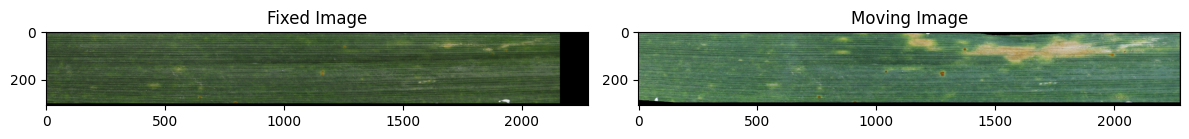

In [6]:
from masking import fetch_masked_image_seq

imgs, masks = fetch_masked_image_seq(leaf, return_masks=True, image_preprocessing=config['image_preprocessing'])
_=plot_image_pair(imgs[0], imgs[ind], subtitle_1="Fixed Image", subtitle_2="Moving Image")

In [7]:
ind = 5
img_fixed = imgs[0]
img_moving = imgs[ind]
mask_fixed = masks[0]
mask_moving = masks[ind]

## Landmark Detection

### Calling LoFTR

LoFTR matches can be detected using `loftr_match`:

Total matches: 5941
Matches with Confidence > 0.5: 4265
Inliers: 3355 (56.47%)


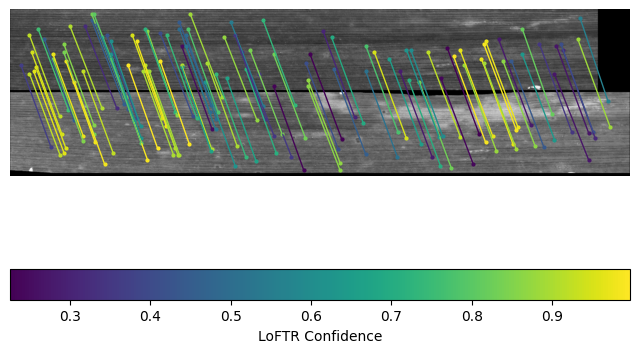

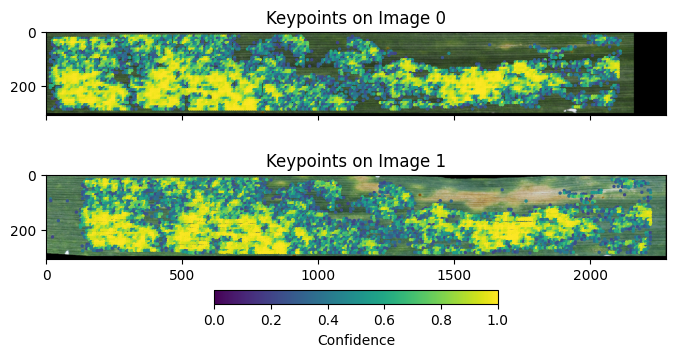

In [8]:
from loftr import loftr_match

mkpts0, mkpts1, confidence, inliers = loftr_match(img_fixed, img_moving, mask_fixed, mask_moving, verbose=True, return_n_matches=False)

_ = plot_matches_conf(img_fixed, mkpts0, img_moving, mkpts1, confidence, N_show=100, vertical=True)
_ = plot_match_coverage(img_fixed, mkpts0, img_moving, mkpts1, confidence, vertical=True)

### Warp Consistency

`check_warp_consistency` handles both match detection and validation of matches using Warp Consistency. The function can be configured using a dictionary as following:

In [9]:
warp_consistency_config = {
    'consistency_tolerance': 5, # tolerance for displacement after traveling through the cycle.
    'transform': {
        'type': 'rotation', # what kind of transformation to use for generating the third image. one of 'rotation' or 'homography'.
        'params': {
            'rotation': -10 # parameter for the transformation
            }
        }
    }

Example function call:

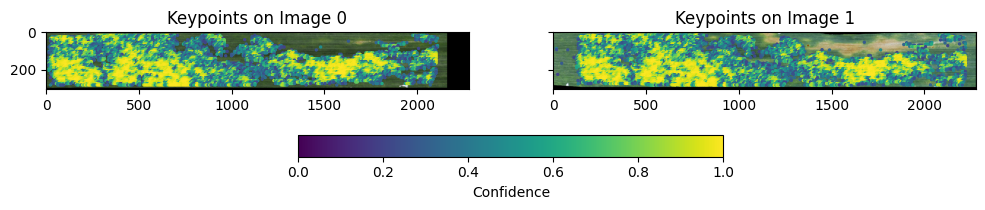

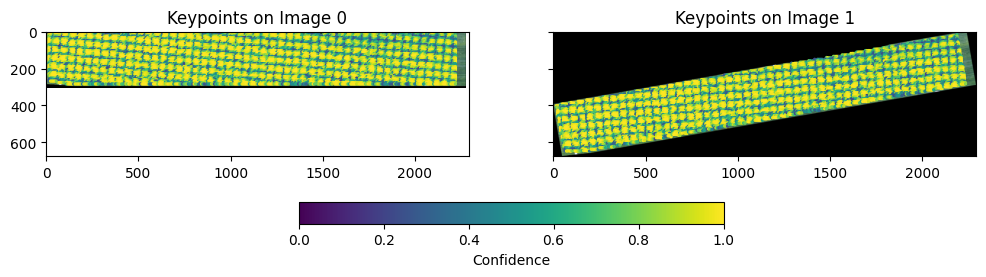

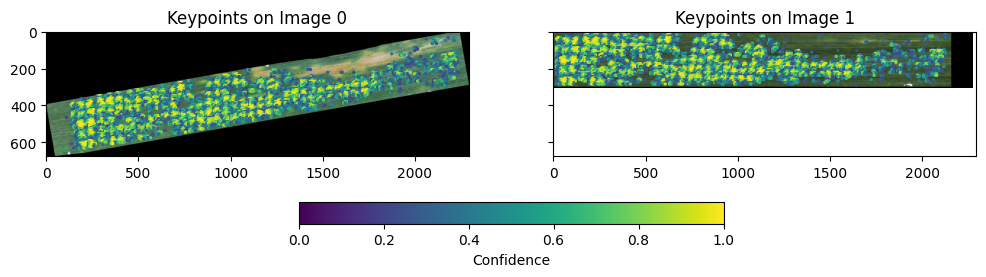

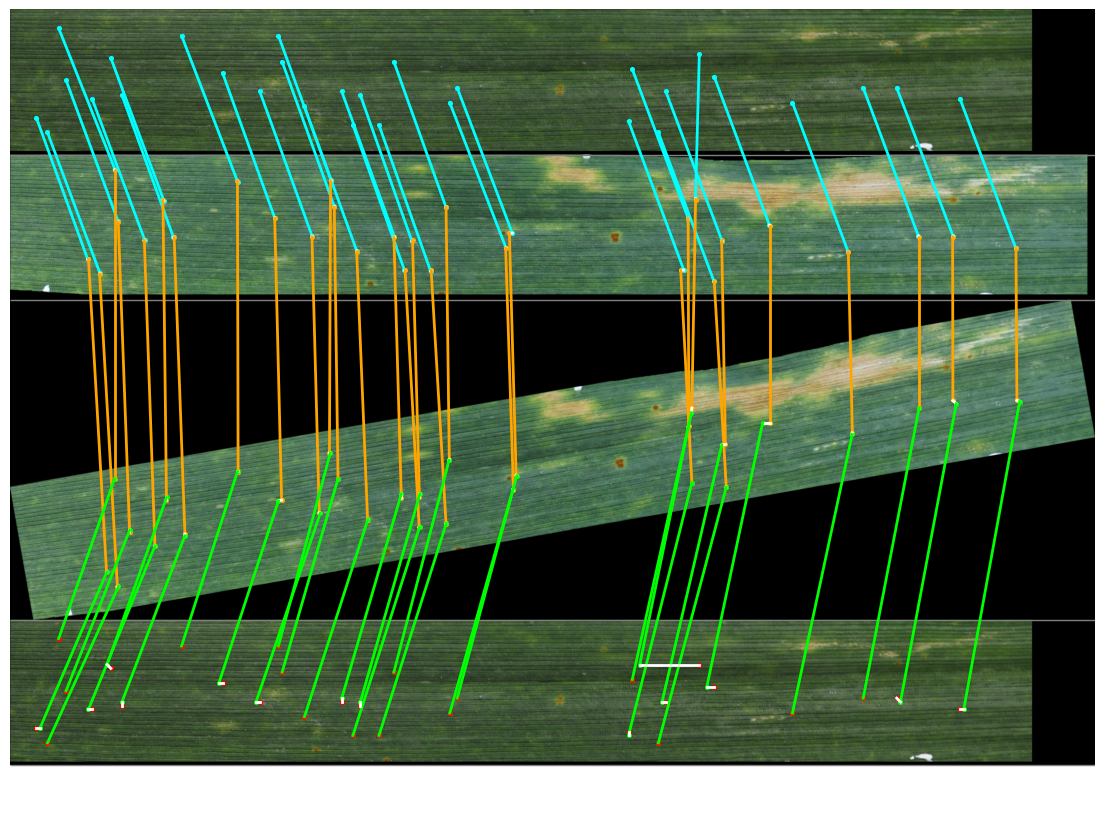

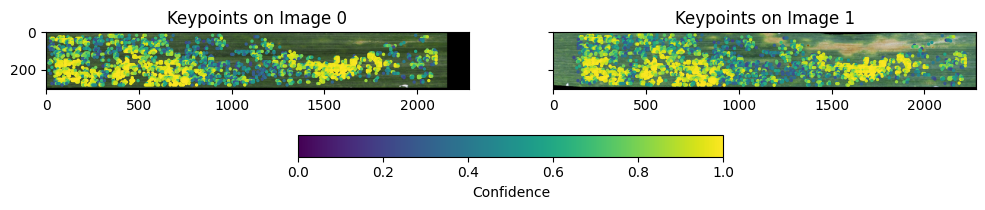

In [10]:
from loftr import check_warp_consistency

mkpts0_consistent, mkpts1_consistent, confidence_consistent = check_warp_consistency(img_fixed, img_moving, mask_fixed, mask_moving, plot_matches=True, **config['warp_consistency'])
# or
# mkpts0_consistent, mkpts1_consistent, confidence_consistent = check_warp_consistency(img_fixed, img_moving, mask_fixed, mask_moving, plot_matches=True, warp_consistency_config)

### Match Filtering

We provide four methods for reducing the number of matches: confidence-based, grid-wise, cluster-wise, or by enforcing a minimum distance. 

The filtering function `filter_matches` can be configured using a dictionary as follows:

In [11]:
filtering_config = {
    'filtering_strategy': 'confidence', # or: 'grid', 'clusters', 'min_distance'
    'n_target': 500, # target number of landmarks to be selected
    'tol': 50, # tolerated deviation from target number of landmarks
    'min_conf': 0.5 # enforced minimum confidence of matches to be considered for selection
    }

Example function call:

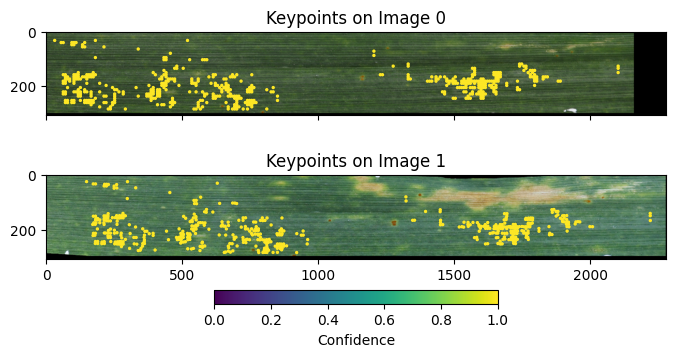

In [12]:
import torch
from loftr import filter_matches

mkpts0_filtered, mkpts1_filtered = filter_matches(
    mkpts0_consistent, mkpts1_consistent, confidence_consistent,
    img_fixed.shape, **filtering_config)

_ = plot_match_coverage(img_fixed, mkpts0_filtered, img_moving, mkpts1_filtered, torch.ones(len(mkpts0_filtered)), vertical=True)

### All-in-One Match Retrieval

The function `fetch_keypoints` performs match detection, warp consistency and filtering all in one. Warp Conistency and match filtering can be configured using dictionaries as above. To disable Warp Consistency, set `warp_consistency = None`.

In [13]:
from loftr import fetch_keypoints
out = fetch_keypoints(img_fixed, img_moving, mask_fixed, mask_moving, warp_consistency=config['warp_consistency'], match_filtering=config['match_filtering'], verbose=False)

mkpts0 = out['mkpts0'] # consistent but unfiltered matches
mkpts1 = out['mkpts1']

mkpts0_filtered = out['mkpts0_filtered'] # filtered matches
mkpts1_filtered = out['mkpts1_filtered']

## Thin Plate Splines

Once we have landmarks, we use Thin Plate Splines to transform our images.  
Notable functions:
- `fit_tps_torch`: Fits a TPS transform between two sets of keypoints.
- `warp_tps_points_torch`: Applies TPS transform to points.
- `warp_tps_torch`: Apply one or more TPS transformations to an image.
- `torch_tps`: Fit a TPS transform between two sets of keypoints and use it to warp the moving image.

Example function calls:

Fitting TPS...
Warping Moving Image...


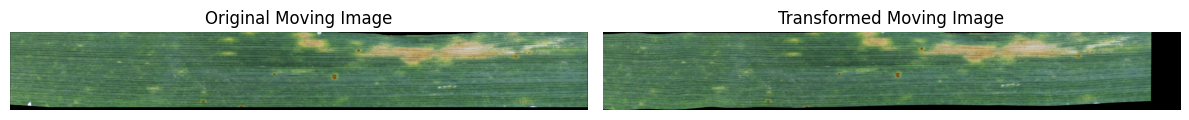

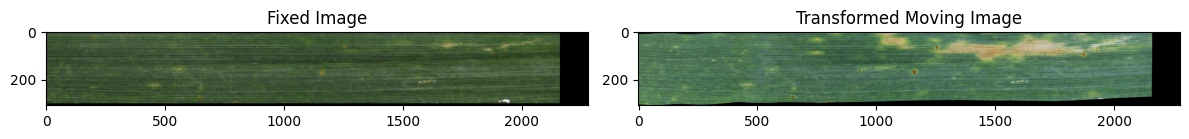

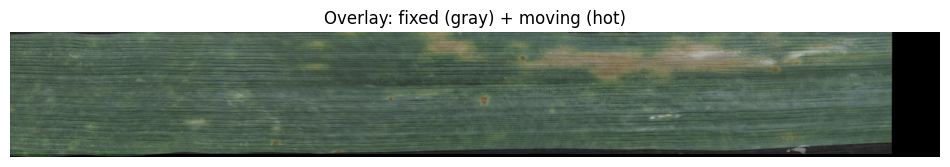

In [14]:
from loftr import torch_tps
warped = torch_tps(mkpts0_filtered, mkpts1_filtered, img_moving, alpha=100, verbose=True)
_ = plot_img_transform(img_moving, warped, plot_keypts=False)
_ = plot_image_pair(img_fixed, warped, subtitle_1="Fixed Image", subtitle_2="Transformed Moving Image")  
_ = plot_overlay(img_fixed, warped)

## Series Registration Functions

We provide a series of functions for image registration of both individual images and full time series:
- `register_single_image`: Registers a single moving image to a fixed image.
- `register_leaf_seq_individual`: Registers all time frames of a leaf to the first frame using individual registration.
- `register_leaf_seq_sequential`: Registers all time frames of a leaf to the first frame using sequential registration.
- `register_leaf_seq_semi_sequential`: Registers all time frames of a leaf to the first frame using ssequentialmi-sequential registration.
- `fetch_registered_image_mask_seq`: Wrapper function for image sequence registration. (More details below.)
- `fetch_preregistered_leaf`: Fetches the ROI registered with Piecewise Affine registration at a specified time point.
- `fetch_preregistered_leaf_seq`: Fetches all ROIs registered with Piecewise Affine registration from all time points.


The function `register_single_image` takes in already preprocessed fixed and moving images and registers them. Warp consistency and match filtering can be configured as before.

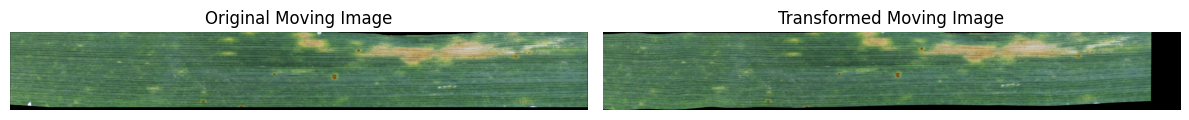

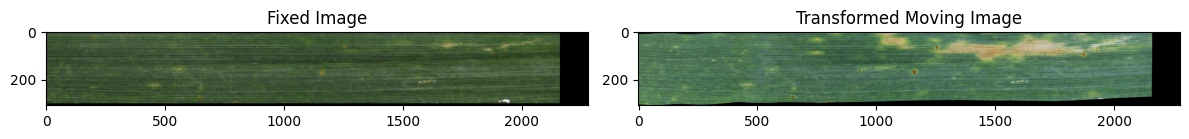

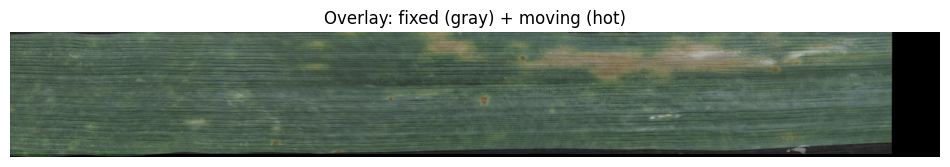

In [15]:
from registration import register_single_image
warped_img, warped_mask = register_single_image(
    img_fixed,
    img_moving, 
    mask_fixed,
    mask_moving,
    smoothing=100.0,     
    return_tps=False,
    plot_loftr_matches=False, 
    warp_consistency=config['warp_consistency'],
    match_filtering=config['match_filtering'],
    verbose=False,
    )

_ = plot_img_transform(img_moving, warped_img, plot_keypts=False)
_ = plot_image_pair(img_fixed, warped_img, subtitle_1="Fixed Image", subtitle_2="Transformed Moving Image")  
_ = plot_overlay(img_fixed, warped_img)

The function `fetch_registered_image_mask_seq` is an all in one wrapper function for the full registration process of the entire leaf sequence for all different methods:
- `"LoFTR + TPS Individual"`: individual registration, using LoFTR for landmark detection and TPS as transformation model.
- `"LoFTR + TPS Sequential"`: sequential registration, using LoFTR for landmark detection and TPS as transformation model.
- `"LoFTR + TPS Semi-Sequential"`: semi-sequential registration, using LoFTR for landmark detection and TPS as transformation model.
- `Piecewise Affine`: fetches the existing ROIs registered with Piecewise Affine registration from the dataset.
- `Baseline`: only pre-rotates the ROIs, no further transformations.

The LoFTR + TPS registration methods can be further configured w.r.t. image preprocessing, warp consistency, match filtering and criterion for semi-sequential registration, as before.

Registering Semi-Sequentially: 100%|██████████| 14/14 [03:53<00:00, 16.66s/it]


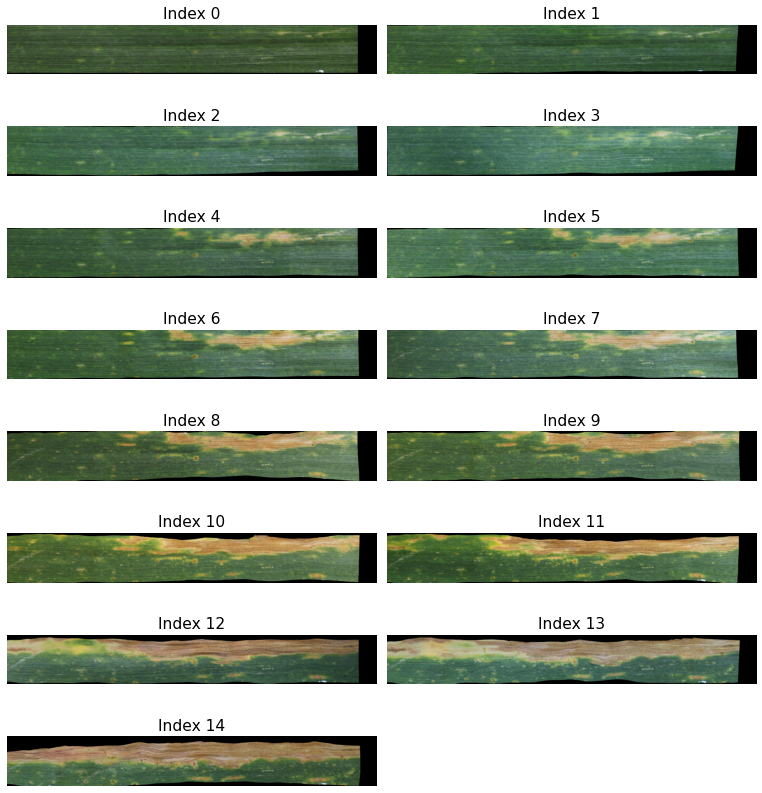

In [16]:
from registration import fetch_registered_image_mask_seq
# method = "Baseline"
# method = "Piecewise Affine"
# method = "LoFTR + TPS Individual"
# method = "LoFTR + TPS Sequential"
method = "LoFTR + TPS Semi-Sequential"
imgs, masks = fetch_registered_image_mask_seq(leaf, method, config)

_ = plot_image_series(imgs)

## Evaluation

For evaluation, we provide a series metrics in `metrics.py`, see below. For most of the intensity-based metrics (such as MSE, NCC, etc.) we provide also a 'masked' version, that only takes into account areas where both images have valid pixels/foreground.  
- `mse`, `mse_masked`: Mean Squared Error between two images.
- `mape`, `mape_masked`: Mean Absolute Percentage Error between two images.
- `local_ncc`, `local_ncc_masked`: Local Normalized Cross-Correlation between two images.
- `nmi`, `nmi_masked`: Normalized Mutual Information between two images.
- `ssim_kornia`: Structural Similarity Index (using Kornia implementation) between two images.
- `tre`: Target Registration Error between two sets of keypoints.
- `iou`: Intersection-over-Union of binary masks.
- `hausdorff`: Hausdorff distance between binary masks.

## Other Utilities

The file `utils.py` contains a variety of utility functions. The most relevant ones are:
- `load_config`: For loading config files.
- `convert_image_to_tensor`: For converting images of varying file types to torch tensors.
- `crop_img` and `crop_margins`: For cropping images.
- `match_sizes_resize` and `match_sizes_resize_batch`: For downscaling images and padding them to match sizes.
- `find_roi_rotation`: For finding the angle of rotation between a minimum area rectangle fit to the ROI and the images axes.
- `transform_img`: For applying different transformations of varying magnitudes.
- `affine_warp_expand`: For applying an affine transformation  while adjusting canvas size to lose no image content.
- `check_orientation`: Rough heuristic for determining whether a 180° rotation is present between images based on behavior of LoFTR matches.